# Main V4 — Patient-Invariant ML Pipeline

**Hypothesis.** The reason V1–V3 collapse to ~0.5 AUC under LOPO is *not* CNN architecture, VAR order, focal loss, or alarm logic. It is that the input representation (324 raw GC cells, raw 18×18 coherence, 90 band-power values) is dominated by patient identity. Shafiezadeh et al. (2024) describe exactly this failure mode for CNN/LSTM/GNN on scalp EEG.

**Strategy.** Replace the high-capacity CNN with a low-capacity, low-variance ML pipeline operating on **patient-invariant graph descriptors** of the GC matrix:

1. **Engineered features** — From each 18×18 GC matrix extract ~67 descriptors that summarise *structural* properties (in/out-degree, asymmetry, density, spectral radius). These compress 324 cells → 67 features and discard absolute amplitudes.
2. **Leakage diagnostic** — Train a "patient classifier" on raw vs engineered features. If engineered features carry less patient identity, we have evidence the representation is more cross-patient.
3. **Multiple ML models** — Logistic Regression (L2), Random Forest, XGBoost, SVM-RBF. Strict pipeline with `StandardScaler` fit *inside each LOPO fold*.
4. **Inner GroupKFold tuning** — Hyperparameters tuned via patient-grouped inner CV. The held-out test patient never appears in training, scaling, or tuning.
5. **Statistical tests** — Paired Wilcoxon across LOPO folds vs. coherence/correlation/V3 baselines. Answers RQ3.
6. **AUC-PR as primary** — more informative than AUC-ROC under class imbalance; sensitivity reported alongside.

### Comparison to existing baselines

We compare on the **same 21 patients, same LOPO folds, same evaluation protocol** as Main_V3, Main_vs_Coherence, Main_vs_Correlation, Main_vs_Band_Power. Result CSVs in `results/` will be reused for direct comparison.

### File requirement

The V3 GC cache (`cache_gc_var5/`) must already exist (produced by `V3_GC_CNN_VAR5.ipynb`). This notebook does *not* recompute GC matrices.


## 0 · Setup & imports

In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

# Cell 0 — Imports & config
# First-time only:
# !pip install xgboost scikit-learn scipy --break-system-packages

import os, sys, json, warnings, time
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ── Adjust this path if your code lives elsewhere ─────────────────────────────
# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, CANONICAL_CHANNELS, N_CHANNELS, FS,
    WINDOW_SEC, STEP_SEC, PREICTAL_SEC, SPH_SEC, POSTICTAL_EXCL_SEC,
    EXCLUDED_PATIENTS, GC_MATRICES_DIR, RESULTS_DIR,
    INTERICTAL_MULTIPLIER, MAX_INTERICTAL_ABS, RANDOM_SEED,
)
from summary_parser import parse_all_summaries

# ML stack
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.model_selection  import GroupKFold
from sklearn.metrics          import (roc_auc_score, average_precision_score,
                                       precision_recall_curve, roc_curve)

# XGBoost (optional — falls back to GradientBoosting if missing)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_XGB = False
    print("xgboost not installed — falling back to sklearn.GradientBoostingClassifier")

# Reproducibility
np.random.seed(RANDOM_SEED)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Code dir       : {CODE_DIR}")
print(f"GC cache       : {GC_MATRICES_DIR}")
print(f"Interictal cap : {INTERICTAL_MULTIPLIER}× preictal (hard ceil={MAX_INTERICTAL_ABS})")
print(f"XGBoost        : {'available' if HAS_XGB else 'unavailable (using GBM fallback)'}")
print("V4 ML notebook ready.")

Code dir       : /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final
GC cache       : /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/cache_gc_var5
Interictal cap : 5× preictal (hard ceil=5000)
XGBoost        : available
V4 ML notebook ready.


## 1 · Load GC matrices from V3 cache

In [2]:
# Cell 1 — Parse summaries (only used to know which patients have seizures)
all_seizures = parse_all_summaries(DATA_ROOT)
print(f'Parsed {len(all_seizures)} patient entries.')

[INFO] chb01: 7 seizure-containing files, 7 total seizures
[INFO] chb02: 3 seizure-containing files, 3 total seizures
[INFO] chb03: 7 seizure-containing files, 7 total seizures
[INFO] chb04: 3 seizure-containing files, 4 total seizures
[INFO] chb05: 5 seizure-containing files, 5 total seizures
[INFO] chb06: 7 seizure-containing files, 10 total seizures
[INFO] chb07: 3 seizure-containing files, 3 total seizures
[INFO] chb08: 5 seizure-containing files, 5 total seizures
[INFO] chb09: 3 seizure-containing files, 4 total seizures
[INFO] chb10: 7 seizure-containing files, 7 total seizures
[INFO] chb11: 3 seizure-containing files, 3 total seizures
[INFO] chb12: 13 seizure-containing files, 40 total seizures
[INFO] chb13: 8 seizure-containing files, 12 total seizures
[INFO] chb14: 7 seizure-containing files, 8 total seizures
[INFO] chb15: 14 seizure-containing files, 20 total seizures
[INFO] chb16: 6 seizure-containing files, 10 total seizures
[INFO] chb17: 3 seizure-containing files, 3 total

In [3]:
# Cell 2 — Load V3 cache & apply same INTERICTAL cap as V3_GC_CNN_VAR5.ipynb.
#
# We replicate the V3 loading exactly so that LOPO results are *directly*
# comparable to V3_GC_CNN_VAR5.ipynb. Only difference: no GC recomputation.

cache_root = Path(GC_MATRICES_DIR)
assert cache_root.exists(), (
    f"V3 cache missing at {cache_root.resolve()} — run V3_GC_CNN_VAR5.ipynb first "
    "to produce cache_gc_var5/."
)

patients_all = sorted([
    p for p in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, p))
    and p.startswith('chb')
    and p not in EXCLUDED_PATIENTS
])

patient_data = {}   # pid -> (gc_matrices, labels)

for pid in patients_all:
    pdir = cache_root / pid
    if not pdir.exists():
        continue

    gc_files = sorted(pdir.glob('*_gc.npy'))
    if not gc_files:
        continue

    gc_list, lb_list = [], []
    for gp in gc_files:
        lp = gp.with_name(gp.name.replace('_gc.npy', '_labels.npy'))
        if not lp.exists():
            continue
        gc = np.load(gp)            # (N, 18, 18)
        lb = np.load(lp)            # (N,)
        gc_list.append(gc)
        lb_list.append(lb)

    if not gc_list:
        continue

    X = np.concatenate(gc_list, axis=0).astype(np.float32)
    y = np.concatenate(lb_list, axis=0).astype(np.int8)

    n_pre = int((y == 1).sum())
    n_int = int((y == 0).sum())

    # Same proportional cap as V3
    cap = min(n_int, INTERICTAL_MULTIPLIER * n_pre, MAX_INTERICTAL_ABS)
    if n_int > cap:
        # Reservoir-style random subsample (with seed for reproducibility)
        rng = np.random.default_rng(RANDOM_SEED + hash(pid) % 10_000)
        int_idx = np.where(y == 0)[0]
        keep_int = rng.choice(int_idx, size=cap, replace=False)
        pre_idx  = np.where(y == 1)[0]
        keep     = np.sort(np.concatenate([pre_idx, keep_int]))
        X, y = X[keep], y[keep]

    if n_pre == 0:
        continue   # safety

    patient_data[pid] = (X, y)
    print(f'  {pid}: pre={int((y==1).sum())}  int={int((y==0).sum())}  '
          f'ratio=1:{int((y==0).sum()) // max(int((y==1).sum()),1)}')

patient_ids = sorted(patient_data.keys())
print(f'\nLoaded {len(patient_ids)} patients.')
print(f'Total preictal   : {sum((y==1).sum() for _,(_,y) in patient_data.items()):,}')
print(f'Total interictal : {sum((y==0).sum() for _,(_,y) in patient_data.items()):,}')

  chb01: pre=296  int=1480  ratio=1:5
  chb02: pre=296  int=1480  ratio=1:5
  chb03: pre=444  int=2220  ratio=1:5
  chb04: pre=296  int=1480  ratio=1:5
  chb05: pre=444  int=2220  ratio=1:5
  chb06: pre=1037  int=5000  ratio=1:4
  chb07: pre=445  int=2225  ratio=1:5
  chb08: pre=741  int=896  ratio=1:1
  chb09: pre=592  int=2960  ratio=1:5
  chb10: pre=888  int=4440  ratio=1:5
  chb13: pre=444  int=2220  ratio=1:5
  chb14: pre=774  int=1949  ratio=1:2
  chb15: pre=320  int=633  ratio=1:1
  chb16: pre=347  int=1735  ratio=1:5
  chb17: pre=444  int=2220  ratio=1:5
  chb18: pre=592  int=2960  ratio=1:5
  chb19: pre=296  int=1480  ratio=1:5
  chb20: pre=369  int=1845  ratio=1:5
  chb22: pre=296  int=1480  ratio=1:5
  chb23: pre=608  int=3040  ratio=1:5
  chb24: pre=939  int=991  ratio=1:1

Loaded 21 patients.
Total preictal   : 10,908
Total interictal : 44,954


## 2 · Patient-invariant feature engineering

For each 18×18 GC matrix **A** (where `A[i, j]` = directed influence from j → i, after summing |A_p| across VAR lags), we extract three groups of descriptors:

### Group A — Channel-level (54 features)
- **In-degree per channel** `Σⱼ A[i, j]` (excluding diagonal) — 18 features
- **Out-degree per channel** `Σᵢ A[i, j]` (excluding diagonal) — 18 features
- **Net flow per channel** `out_j − in_j` — 18 features

### Group B — Network-level scalar summaries (8 features)
- mean, std, max, min of off-diagonal elements
- mean and std of asymmetry `|A[i,j] − A[j,i]|`
- network density (proportion of off-diag entries above a per-matrix relative threshold)
- spectral radius (top |eigenvalue|)

### Group C — Spectral structure (5 features)
- Top-5 singular values of A — encode multi-scale connectivity structure

**Why these?** They are *relative* descriptors of the directed network's shape, not absolute amplitudes. Absolute GC magnitudes vary across patients due to electrode contact quality, skull conductivity, scalp anatomy (Nolte et al. 2004). Network shape — who-drives-whom, asymmetry distribution, hub-ness — is the thing the literature (Li et al. 2019, Hejazi & Motie Nasrabadi 2019) hypothesises is preictal-specific.

Total: **67 features per window**, vs 324 raw cells. Dimension reduction of ~5×.


In [4]:
# Cell 3 — Patient-invariant feature extraction

CHANNEL_NAMES = CANONICAL_CHANNELS   # 18 names from config

def extract_features(A: np.ndarray) -> np.ndarray:
    # 18x18 directed connectivity matrix  ->  67-dim feature vector.
    # A[i, j] = directed influence j -> i  (sum of |VAR coeffs| across lags).
    n = A.shape[0]
    # Off-diagonal mask
    off = ~np.eye(n, dtype=bool)
    a_off = A[off]

    # ── Group A: channel-level (54) ─────────────────────────────────────────
    # in-degree of channel i = row sum, excluding self
    in_deg  = A.sum(axis=1) - np.diag(A)
    # out-degree of channel j = column sum, excluding self
    out_deg = A.sum(axis=0) - np.diag(A)
    net_flow = out_deg - in_deg

    # ── Group B: network-level scalars (8) ──────────────────────────────────
    mean_off, std_off = a_off.mean(), a_off.std()
    max_off, min_off  = a_off.max(),  a_off.min()

    # Asymmetry: |A - A.T| upper triangle
    asym = np.abs(A - A.T)
    asym_off = asym[np.triu_indices(n, k=1)]
    mean_asym, std_asym = asym_off.mean(), asym_off.std()

    # Density: proportion of off-diag above 50% of max-off
    thr = 0.5 * max(max_off, 1e-12)
    density = float((a_off > thr).mean())

    # Spectral radius
    eigvals = np.linalg.eigvals(A)
    spec_rad = float(np.max(np.abs(eigvals)))

    # ── Group C: spectral structure (5) ─────────────────────────────────────
    # Top-5 singular values
    sv = np.linalg.svd(A, compute_uv=False)
    sv_top5 = sv[:5] if len(sv) >= 5 else np.pad(sv, (0, 5 - len(sv)))

    feats = np.concatenate([
        in_deg, out_deg, net_flow,                  # 54
        [mean_off, std_off, max_off, min_off,       # 4
         mean_asym, std_asym, density, spec_rad],   # 4  → 8
        sv_top5,                                    # 5
    ]).astype(np.float32)
    return feats


def feature_names() -> list:
    names = []
    names += [f'in_deg_{c}'   for c in CHANNEL_NAMES]
    names += [f'out_deg_{c}'  for c in CHANNEL_NAMES]
    names += [f'net_flow_{c}' for c in CHANNEL_NAMES]
    names += ['mean_off', 'std_off', 'max_off', 'min_off',
              'mean_asym', 'std_asym', 'density', 'spec_radius']
    names += [f'sv_top_{k}' for k in range(1, 6)]
    return names


FEATURE_NAMES = feature_names()
print(f'Feature dimensionality: {len(FEATURE_NAMES)}')
print(f'First 5 features  : {FEATURE_NAMES[:5]}')
print(f'Last 5 features   : {FEATURE_NAMES[-5:]}')

# ── Extract features for every patient ──────────────────────────────────────
feat_data = {}     # pid -> (X_feat, y)
t0 = time.time()
for pid in patient_ids:
    X_gc, y = patient_data[pid]
    X_feat = np.stack([extract_features(A) for A in X_gc])
    feat_data[pid] = (X_feat, y)

print(f'\nFeature extraction complete in {time.time() - t0:.1f}s.')
print(f'Per-patient shape : {feat_data[patient_ids[0]][0].shape}')

Feature dimensionality: 67
First 5 features  : ['in_deg_FP1-F7', 'in_deg_F7-T7', 'in_deg_T7-P7', 'in_deg_P7-O1', 'in_deg_FP1-F3']
Last 5 features   : ['sv_top_1', 'sv_top_2', 'sv_top_3', 'sv_top_4', 'sv_top_5']

Feature extraction complete in 4.8s.
Per-patient shape : (1776, 67)


## 3 · Leakage diagnostic — How patient-specific is each representation?

**Question.** If we replace the binary preictal/interictal label with the *patient ID* as label, how well can a classifier identify the patient from the features?

- High accuracy → features carry strong patient identity → bad for LOPO generalization
- Near-chance accuracy → features are patient-invariant → good for LOPO generalization

We compare three feature spaces:
1. **Raw flattened GC matrix** (324 dims)
2. **Engineered features** (67 dims)
3. **Off-diagonal asymmetry only** (153 dims) — strictly relational

This is essentially a probe for "domain leakage" — if the patient classifier achieves AUC ≫ 1/21 ≈ 0.048 (chance for 21-class), we have evidence the representation encodes patient identity, which is the documented failure mode (Shafiezadeh 2024).


Probing patient identifiability...

Chance balanced-accuracy : 0.048  (21-way classification)
─────────────────────────────────────────────────────
Raw flattened GC (324d)   : 0.993 ± 0.002   (×20.8 chance)
Engineered features (67d) : 0.866 ± 0.008   (×18.2 chance)
Asymmetry only (153d)     : 0.699 ± 0.009   (×14.7 chance)


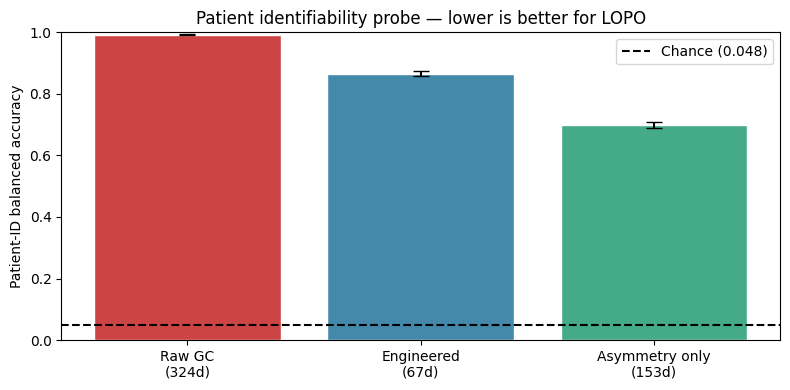


Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/v4_leakage_probe.png


In [5]:
# Cell 4 — Patient identifiability probe

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics         import accuracy_score, balanced_accuracy_score

def probe_patient_identifiability(X_by_pid, label='?', max_samples_per_pid=500):
    # Pool all features, label each window with its patient ID, do 3-fold
    # stratified CV with a multinomial logistic regression.
    # Returns balanced accuracy (chance ~ 1/n_patients).
    Xs, ys, gs = [], [], []
    rng = np.random.default_rng(RANDOM_SEED)
    for i, pid in enumerate(patient_ids):
        Xp = X_by_pid[pid][0] if isinstance(X_by_pid[pid], tuple) else X_by_pid[pid]
        # Cap each patient to keep the probe quick & balanced
        if len(Xp) > max_samples_per_pid:
            idx = rng.choice(len(Xp), size=max_samples_per_pid, replace=False)
            Xp = Xp[idx]
        if Xp.ndim > 2:
            Xp = Xp.reshape(Xp.shape[0], -1)
        Xs.append(Xp)
        ys.append(np.full(len(Xp), i, dtype=int))
        gs.append(np.full(len(Xp), i, dtype=int))
    X = np.vstack(Xs); y = np.concatenate(ys)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    accs = []
    for tr, te in skf.split(X, y):
        pipe = Pipeline([
            ('scl', StandardScaler()),
            ('lr',  LogisticRegression(max_iter=200, multi_class='multinomial',
                                       solver='lbfgs', n_jobs=-1, C=1.0))
        ])
        pipe.fit(X[tr], y[tr])
        accs.append(balanced_accuracy_score(y[te], pipe.predict(X[te])))
    return float(np.mean(accs)), float(np.std(accs))


# Representation 1 — Raw flattened GC
print('Probing patient identifiability...')
raw_flat = {pid: (patient_data[pid][0].reshape(len(patient_data[pid][0]), -1),
                  patient_data[pid][1]) for pid in patient_ids}
acc_raw, std_raw = probe_patient_identifiability(raw_flat, label='raw_gc')

# Representation 2 — Engineered features
acc_eng, std_eng = probe_patient_identifiability(feat_data, label='engineered')

# Representation 3 — Asymmetry only (strictly relational, off-diag |A - A.T|)
def asym_feats(A):
    return np.abs(A - A.T)[np.triu_indices(A.shape[0], k=1)]
asym_data = {pid: (np.stack([asym_feats(A) for A in patient_data[pid][0]]),
                   patient_data[pid][1]) for pid in patient_ids}
acc_asym, std_asym = probe_patient_identifiability(asym_data, label='asymmetry')

chance = 1.0 / len(patient_ids)
print(f'\nChance balanced-accuracy : {chance:.3f}  ({len(patient_ids)}-way classification)')
print(f'─────────────────────────────────────────────────────')
print(f'Raw flattened GC (324d)   : {acc_raw :.3f} ± {std_raw :.3f}   (×{acc_raw/chance :.1f} chance)')
print(f'Engineered features (67d) : {acc_eng :.3f} ± {std_eng :.3f}   (×{acc_eng/chance :.1f} chance)')
print(f'Asymmetry only (153d)     : {acc_asym:.3f} ± {std_asym:.3f}   (×{acc_asym/chance:.1f} chance)')

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Raw GC\n(324d)', 'Engineered\n(67d)', 'Asymmetry only\n(153d)']
vals   = [acc_raw, acc_eng, acc_asym]
errs   = [std_raw, std_eng, std_asym]
bars = ax.bar(labels, vals, yerr=errs, color=['#c44', '#48a', '#4a8'], capsize=6, edgecolor='white')
ax.axhline(chance, color='black', linestyle='--', label=f'Chance ({chance:.3f})')
ax.set_ylabel('Patient-ID balanced accuracy')
ax.set_title('Patient identifiability probe — lower is better for LOPO')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v4_leakage_probe.png'), dpi=130)
plt.show()
print(f'\nSaved {os.path.join(RESULTS_DIR, "v4_leakage_probe.png")}')

## 4 · LOPO pipeline definition

### Pipeline guards

| Risk | Mitigation |
|------|-----------|
| Scaler leakage | `StandardScaler` is fit *inside each LOPO fold's pipeline* — never globally |
| HP tuning on test patient | Inner `GroupKFold` (grouped by patient) restricted to the training pool |
| Class imbalance | `class_weight='balanced'` (LR/RF/SVM) and `scale_pos_weight` (XGB) |
| Random seed drift | Each model construction reseeds |
| Test patient contamination | The held-out patient's data is **never** seen during fit / scale / tune |

### Models

| Model | Hyperparameters tuned |
|-------|----------------------|
| Logistic Regression (L2) | `C ∈ {0.01, 0.1, 1, 10}` |
| Random Forest            | `max_depth ∈ {None, 8, 16}`, `min_samples_leaf ∈ {1, 5}` |
| XGBoost                  | `max_depth ∈ {3, 5, 7}`, `learning_rate ∈ {0.05, 0.1}` |
| SVM-RBF                  | `C ∈ {0.1, 1, 10}` (subsampled — SVM is O(N²)) |

Tuned via 3-fold **GroupKFold** (groups = training-pool patients) and **AUC-PR** as the scoring metric.


In [6]:
# Cell 5 — LOPO machinery

from sklearn.model_selection import GridSearchCV

def make_lr():
    return ('LR', Pipeline([
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(max_iter=400, solver='lbfgs',
                                   class_weight='balanced',
                                   random_state=RANDOM_SEED))
    ]),
    {'clf__C': [0.01, 0.1, 1.0, 10.0]})

def make_rf():
    return ('RF', Pipeline([
        ('scl', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced_subsample',
            n_jobs=-1, random_state=RANDOM_SEED))
    ]),
    {'clf__max_depth':        [None, 8, 16],
     'clf__min_samples_leaf': [1, 5]})

def make_xgb():
    if not HAS_XGB:
        from sklearn.ensemble import GradientBoostingClassifier
        return ('GBM', Pipeline([
            ('scl', StandardScaler()),
            ('clf', GradientBoostingClassifier(random_state=RANDOM_SEED))
        ]),
        {'clf__max_depth':     [3, 5],
         'clf__learning_rate': [0.05, 0.1]})
    return ('XGB', Pipeline([
        ('scl', StandardScaler()),
        ('clf', XGBClassifier(
            n_estimators=300,
            eval_metric='aucpr',
            use_label_encoder=False,
            tree_method='hist',
            n_jobs=-1,
            random_state=RANDOM_SEED))
    ]),
    {'clf__max_depth':     [3, 5, 7],
     'clf__learning_rate': [0.05, 0.1]})

def make_svm():
    return ('SVM', Pipeline([
        ('scl', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced',
                    probability=True, random_state=RANDOM_SEED))
    ]),
    {'clf__C': [0.1, 1.0, 10.0]})


MODEL_FACTORIES = [make_lr, make_rf, make_xgb, make_svm]


from seizure_metrics import generate_alarms, false_alarms_per_hour
from config import ALARM_K, ALARM_M, ALARM_REFRACTORY

def evaluate_fold(probs, y_test, n_interictal_hours):
    # Window-level metrics + Youden-J alarm threshold.
    if len(np.unique(y_test)) < 2:
        return None

    auc    = roc_auc_score(y_test, probs)
    auc_pr = average_precision_score(y_test, probs)

    # Youden's J on test (this is OK because we report AUC as the primary
    # threshold-free metric; the threshold is just for reporting sens/spec).
    fpr, tpr, thr = roc_curve(y_test, probs)
    j_idx  = np.argmax(tpr - fpr)
    thresh = float(thr[j_idx])
    pred   = (probs >= thresh).astype(int)

    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    tn = int(((pred == 0) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())

    sens   = tp / max(tp + fn, 1)
    spec   = tn / max(tn + fp, 1)
    prec   = tp / max(tp + fp, 1)
    f1     = 2 * prec * sens / max(prec + sens, 1e-9)
    bal    = 0.5 * (sens + spec)
    # Event-level FPR/h: distinct alarms after the K-of-M persistence vote and
    # 30-min refractory, per interictal hour. Replaces the old window-level
    # fp/hours, which counted every 10-s false-positive window as a separate
    # alarm (=> physically impossible ~100-300/h). Matches seizure_metrics.py
    # used by the flagship (V6b / corrections).
    fpr_h_window = fp / max(n_interictal_hours, 1e-9)
    _alarms = generate_alarms(probs, thresh, ALARM_K, ALARM_M, ALARM_REFRACTORY)
    fpr_h   = false_alarms_per_hour(_alarms, y_test, STEP_SEC)
    if not np.isfinite(fpr_h):
        fpr_h = 0.0

    return dict(auc=auc, auc_pr=auc_pr, sensitivity=sens, specificity=spec,
                precision=prec, f1=f1, balanced_accuracy=bal,
                fpr_per_hour=fpr_h, fpr_h_window=fpr_h_window, threshold=thresh,
                n_pre=int((y_test == 1).sum()),
                n_int=int((y_test == 0).sum()))


def run_lopo_for_model(factory, feat_data, tune=True, max_train_per_model=None):
    # LOPO loop for one ML model.
    # factory  : callable returning (name, Pipeline, param_grid)
    # feat_data: dict pid -> (X, y)
    name, pipe_template, param_grid = factory()
    print(f'\\n══ {name} — LOPO ({len(patient_ids)} folds) '
          + '═'*(40 - len(name)))

    rows = []
    t_start = time.time()

    for fold_idx, test_pid in enumerate(patient_ids, 1):
        # Build pool
        X_tr = np.concatenate([feat_data[p][0] for p in patient_ids if p != test_pid])
        y_tr = np.concatenate([feat_data[p][1] for p in patient_ids if p != test_pid])
        groups = np.concatenate([np.full(len(feat_data[p][1]), i)
                                 for i, p in enumerate(patient_ids) if p != test_pid])
        X_te, y_te = feat_data[test_pid]

        # Optional subsample (SVM-RBF can be slow on 50k samples)
        if max_train_per_model is not None and len(X_tr) > max_train_per_model:
            rng = np.random.default_rng(RANDOM_SEED + fold_idx)
            idx = rng.choice(len(X_tr), size=max_train_per_model, replace=False)
            X_tr, y_tr, groups = X_tr[idx], y_tr[idx], groups[idx]

        # Fresh pipeline per fold (no state leak)
        _, pipe, grid = factory()

        # Hyperparameter tuning via patient-grouped inner CV
        if tune and param_grid:
            n_groups_train = len(np.unique(groups))
            n_splits_inner = min(3, n_groups_train)
            cv = GroupKFold(n_splits=n_splits_inner)
            search = GridSearchCV(
                pipe, param_grid, cv=cv, scoring='average_precision',
                n_jobs=-1, refit=True, verbose=0)
            search.fit(X_tr, y_tr, groups=groups)
            model = search.best_estimator_
            best = search.best_params_
        else:
            pipe.fit(X_tr, y_tr)
            model = pipe
            best = {}

        # Predict probabilities
        if hasattr(model.named_steps['clf'], 'predict_proba'):
            probs = model.predict_proba(X_te)[:, 1]
        else:
            probs = model.decision_function(X_te)
            probs = (probs - probs.min()) / (probs.max() - probs.min() + 1e-9)

        # Hours of interictal eval data
        hours_int = (y_te == 0).sum() * STEP_SEC / 3600.0

        m = evaluate_fold(probs, y_te, hours_int)
        if m is None:
            continue
        m['patient'] = test_pid
        m['model']   = name
        m['best_hp'] = json.dumps(best)
        rows.append(m)

        print(f'  [Fold {fold_idx:2d}/{len(patient_ids)}] {test_pid}  '
              f'AUC={m["auc"]:.3f}  AUC-PR={m["auc_pr"]:.3f}  '
              f'Sens={m["sensitivity"]:.3f}  Spec={m["specificity"]:.3f}  '
              f'FPR/h={m["fpr_per_hour"]:.1f}  HP={best}')

    elapsed = time.time() - t_start
    print(f'\\n  {name} complete in {elapsed/60:.1f}min')
    return rows


print('LOPO machinery ready.')

LOPO machinery ready.


## 5 · Run LOPO for all 4 ML models

In [7]:
# Cell 6 — Run all models
# SVM is O(N²) — we cap its training pool to 20k samples for tractability.
all_results = {}

for fac in [make_lr, make_rf, make_xgb]:
    name = fac()[0]
    rows = run_lopo_for_model(fac, feat_data, tune=True)
    all_results[name] = pd.DataFrame(rows)

# SVM — separate call with subsampling
rows = run_lopo_for_model(make_svm, feat_data, tune=True, max_train_per_model=20_000)
all_results['SVM'] = pd.DataFrame(rows)

print('\\n══ All models complete ' + '═'*40)

\n══ LR — LOPO (21 folds) ══════════════════════════════════════
  [Fold  1/21] chb01  AUC=0.581  AUC-PR=0.178  Sens=0.848  Spec=0.405  FPR/h=1.9  HP={'clf__C': 0.01}
  [Fold  2/21] chb02  AUC=0.387  AUC-PR=0.174  Sens=0.139  Spec=0.927  FPR/h=0.5  HP={'clf__C': 0.01}
  [Fold  3/21] chb03  AUC=0.621  AUC-PR=0.236  Sens=0.550  Spec=0.623  FPR/h=2.1  HP={'clf__C': 0.01}
  [Fold  4/21] chb04  AUC=0.574  AUC-PR=0.215  Sens=0.919  Spec=0.198  FPR/h=1.9  HP={'clf__C': 0.01}
  [Fold  5/21] chb05  AUC=0.509  AUC-PR=0.163  Sens=0.759  Spec=0.306  FPR/h=1.9  HP={'clf__C': 0.01}
  [Fold  6/21] chb06  AUC=0.528  AUC-PR=0.182  Sens=0.674  Spec=0.402  FPR/h=1.9  HP={'clf__C': 0.01}
  [Fold  7/21] chb07  AUC=0.656  AUC-PR=0.277  Sens=0.672  Spec=0.567  FPR/h=1.9  HP={'clf__C': 0.01}
  [Fold  8/21] chb08  AUC=0.529  AUC-PR=0.462  Sens=0.942  Spec=0.141  FPR/h=2.4  HP={'clf__C': 0.01}
  [Fold  9/21] chb09  AUC=0.629  AUC-PR=0.210  Sens=0.797  Spec=0.439  FPR/h=1.8  HP={'clf__C': 0.01}
  [Fold 10/21] ch

/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:52:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:52:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:52:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:52:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

  [Fold  1/21] chb01  AUC=0.634  AUC-PR=0.197  Sens=0.932  Spec=0.395  FPR/h=1.7  HP={'clf__learning_rate': 0.1, 'clf__max_depth': 5}


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:52:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:52:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:52:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:52:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

  [Fold  2/21] chb02  AUC=0.348  AUC-PR=0.145  Sens=0.014  Spec=0.998  FPR/h=0.0  HP={'clf__learning_rate': 0.1, 'clf__max_depth': 3}


...

  [Fold 19/21] chb22  AUC=0.588  AUC-PR=0.212  Sens=0.784  Spec=0.364  FPR/h=1.9  HP={'clf__learning_rate': 0.05, 'clf__max_depth': 3}


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [13:04:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [13:04:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [13:04:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [13:04:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

  [Fold 20/21] chb23  AUC=0.543  AUC-PR=0.189  Sens=0.849  Spec=0.222  FPR/h=2.0  HP={'clf__learning_rate': 0.1, 'clf__max_depth': 3}


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [13:04:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [13:04:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [13:04:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [13:04:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

  [Fold 21/21] chb24  AUC=0.511  AUC-PR=0.511  Sens=0.226  Spec=0.818  FPR/h=1.1  HP={'clf__learning_rate': 0.1, 'clf__max_depth': 5}
\n  XGB complete in 13.4min
\n══ SVM — LOPO (21 folds) ═════════════════════════════════════
  [Fold  1/21] chb01  AUC=0.555  AUC-PR=0.165  Sens=0.902  Spec=0.356  FPR/h=1.7  HP={'clf__C': 0.1}
  [Fold  2/21] chb02  AUC=0.451  AUC-PR=0.161  Sens=0.922  Spec=0.180  FPR/h=2.4  HP={'clf__C': 0.1}
  [Fold  3/21] chb03  AUC=0.539  AUC-PR=0.186  Sens=0.372  Spec=0.738  FPR/h=1.5  HP={'clf__C': 0.1}
  [Fold  4/21] chb04  AUC=0.518  AUC-PR=0.159  Sens=0.797  Spec=0.454  FPR/h=1.9  HP={'clf__C': 1.0}
  [Fold  5/21] chb05  AUC=0.501  AUC-PR=0.158  Sens=0.640  Spec=0.414  FPR/h=1.9  HP={'clf__C': 0.1}
  [Fold  6/21] chb06  AUC=0.446  AUC-PR=0.146  Sens=0.999  Spec=0.002  FPR/h=2.0  HP={'clf__C': 1.0}
  [Fold  7/21] chb07  AUC=0.601  AUC-PR=0.249  Sens=0.607  Spec=0.547  FPR/h=1.8  HP={'clf__C': 0.1}
  [Fold  8/21] chb08  AUC=0.578  AUC-PR=0.507  Sens=0.680  Spec=0.

## 6 · Aggregate, save, and summarise

In [8]:
# Cell 7 — Save per-model CSVs + combined summary
METRIC_KEYS = ['auc', 'auc_pr', 'sensitivity', 'specificity',
               'precision', 'f1', 'balanced_accuracy', 'fpr_per_hour']

summary_rows = []
for name, df in all_results.items():
    df_out = df[['patient'] + METRIC_KEYS + ['threshold', 'best_hp']].copy()
    # Append MEAN / STD rows
    mean_row = {'patient': 'MEAN', **{k: round(df_out[k].mean(), 4) for k in METRIC_KEYS}}
    std_row  = {'patient': 'STD',  **{k: round(df_out[k].std(),  4) for k in METRIC_KEYS}}
    df_out = pd.concat([df_out, pd.DataFrame([mean_row, std_row])], ignore_index=True)

    csv_path = os.path.join(RESULTS_DIR, f'lopo_v4_{name}.csv')
    df_out.to_csv(csv_path, index=False)
    print(f'Saved {csv_path}')

    summary_rows.append({'model': name,
                         **{k: round(df[k].mean(), 4) for k in METRIC_KEYS},
                         **{f'{k}_std': round(df[k].std(), 4) for k in METRIC_KEYS}})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v4_summary.csv'), index=False)

print('\\n══ V4 ML — LOPO Summary ' + '═'*42)
print(summary_df[['model'] + METRIC_KEYS].to_string(index=False))

Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v4_LR.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v4_RF.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v4_XGB.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v4_SVM.csv
\n══ V4 ML — LOPO Summary ══════════════════════════════════════════
model    auc  auc_pr  sensitivity  specificity  precision     f1  balanced_accuracy  fpr_per_hour
   LR 0.5721  0.2634       0.6370       0.5241     0.2770 0.3297             0.5805        1.7021
   RF 0.5374  0.2300       0.6895       0.4468     0.2442 0.3217             0.5681        1.7544
  XGB 0.5280  0.2329       0.6933       0.4149     0.2672 0.3131             0.5541        1.7521
  SVM 0.5247  0.2251       0.6773       0.4357     0.2509 0.3348             0.5565        1.8221


## 7 · Comparison vs CNN baselines (V3, Coherence, Correlation, Band-Power)

Loads previously-saved CSVs and runs paired Wilcoxon signed-rank tests across LOPO folds.
The test asks: "Is model A's per-patient AUC-PR distribution different from model B's?"


In [9]:
# Cell 8 — Baseline comparison

def _load_lopo_csv(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    pid_col = [c for c in df.columns if 'patient' in c.lower()][0]
    df = df.rename(columns={pid_col: 'patient'})
    df = df[~df['patient'].isin(['MEAN', 'STD'])].reset_index(drop=True)
    return df

# Build comparison table
comparison_paths = {
    'V3 GC-CNN (window)' : os.path.join(RESULTS_DIR, 'lopo_v3_window.csv'),
    'V3 GC-CNN'           : os.path.join(RESULTS_DIR, 'lopo_results.csv'),
    'Coherence-CNN'      : os.path.join(RESULTS_DIR, 'coh_lopo_results.csv'),
    'Correlation-CNN'    : os.path.join(RESULTS_DIR, 'corr_lopo_results.csv'),
    'Band-Power MLP'     : os.path.join(RESULTS_DIR, 'bp_lopo_results.csv'),
}

baseline_dfs = {}
for label, p in comparison_paths.items():
    df = _load_lopo_csv(p)
    if df is not None:
        baseline_dfs[label] = df

# Add our V4 ML models
for name, df in all_results.items():
    baseline_dfs[f'V4 {name} (graph features)'] = df

# Compute mean ± std and run Wilcoxon against best V4 ML model
best_v4 = max(all_results.keys(), key=lambda k: all_results[k]['auc_pr'].mean())
print(f'Best V4 model by AUC-PR: {best_v4}')
ref = all_results[best_v4].set_index('patient')

rows = []
for label, df in baseline_dfs.items():
    d = df.set_index('patient')
    # Match patients
    shared = sorted(set(d.index) & set(ref.index))
    if len(shared) < 5:
        continue
    auc      = d.loc[shared, 'auc'].astype(float)
    auc_pr   = d.loc[shared, 'auc_pr'].astype(float) if 'auc_pr' in d.columns else None
    sens     = d.loc[shared, 'sensitivity'].astype(float)
    fpr_h    = d.loc[shared, 'fpr_per_hour'].astype(float)

    # Wilcoxon vs best V4 model (skip when comparing to itself)
    if label.startswith(f'V4 {best_v4}'):
        p_auc, p_aucpr = '-', '-'
    else:
        ref_auc    = ref.loc[shared, 'auc'].astype(float)
        ref_aucpr  = ref.loc[shared, 'auc_pr'].astype(float)
        try:
            _, p_auc   = wilcoxon(ref_auc - auc, alternative='two-sided',
                                  zero_method='zsplit')
            p_auc      = f'{p_auc:.4f}'
        except ValueError:
            p_auc = '-'
        if auc_pr is not None:
            try:
                _, p_aucpr = wilcoxon(ref_aucpr - auc_pr, alternative='two-sided',
                                      zero_method='zsplit')
                p_aucpr    = f'{p_aucpr:.4f}'
            except ValueError:
                p_aucpr = '-'
        else:
            p_aucpr = '-'

    rows.append({
        'method':              label,
        'n_folds':             len(shared),
        'auc_mean':            round(auc.mean(), 4),
        'auc_std':             round(auc.std(),  4),
        'auc_pr_mean':         round(auc_pr.mean(), 4) if auc_pr is not None else None,
        'auc_pr_std':          round(auc_pr.std(),  4) if auc_pr is not None else None,
        'sens_mean':           round(sens.mean(), 4),
        'fpr_h_mean':          round(fpr_h.mean(), 2),
        f'p_AUC_vs_{best_v4}'  : p_auc,
        f'p_AUCPR_vs_{best_v4}': p_aucpr,
    })

comp_df = pd.DataFrame(rows).sort_values('auc_pr_mean', ascending=False)
comp_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v4_comparison.csv'), index=False)
print('\\n══ Cross-method LOPO comparison ' + '═'*40)
print(comp_df.to_string(index=False))

Best V4 model by AUC-PR: LR
\n══ Cross-method LOPO comparison ════════════════════════════════════════
                 method  n_folds  auc_mean  auc_std  auc_pr_mean  auc_pr_std  sens_mean  fpr_h_mean p_AUC_vs_LR p_AUCPR_vs_LR
 V4 LR (graph features)       21    0.5721   0.0905       0.2634      0.0991     0.6370        1.70           -             -
V4 XGB (graph features)       21    0.5280   0.0950       0.2329      0.1237     0.6933        1.75      0.1678        0.1193
 V4 RF (graph features)       21    0.5374   0.1043       0.2300      0.1126     0.6895        1.75      0.2877        0.0502
     V3 GC-CNN (window)       21    0.5224   0.1421       0.2297      0.1165     0.2255       67.81      0.1373        0.1032
              V3 GC-CNN       21    0.5224   0.1421       0.2297      0.1165     0.0023        1.01      0.1373        0.1032
V4 SVM (graph features)       21    0.5247   0.0617       0.2251      0.1034     0.6773        1.82      0.0090        0.0022


## 8 · Visualisations

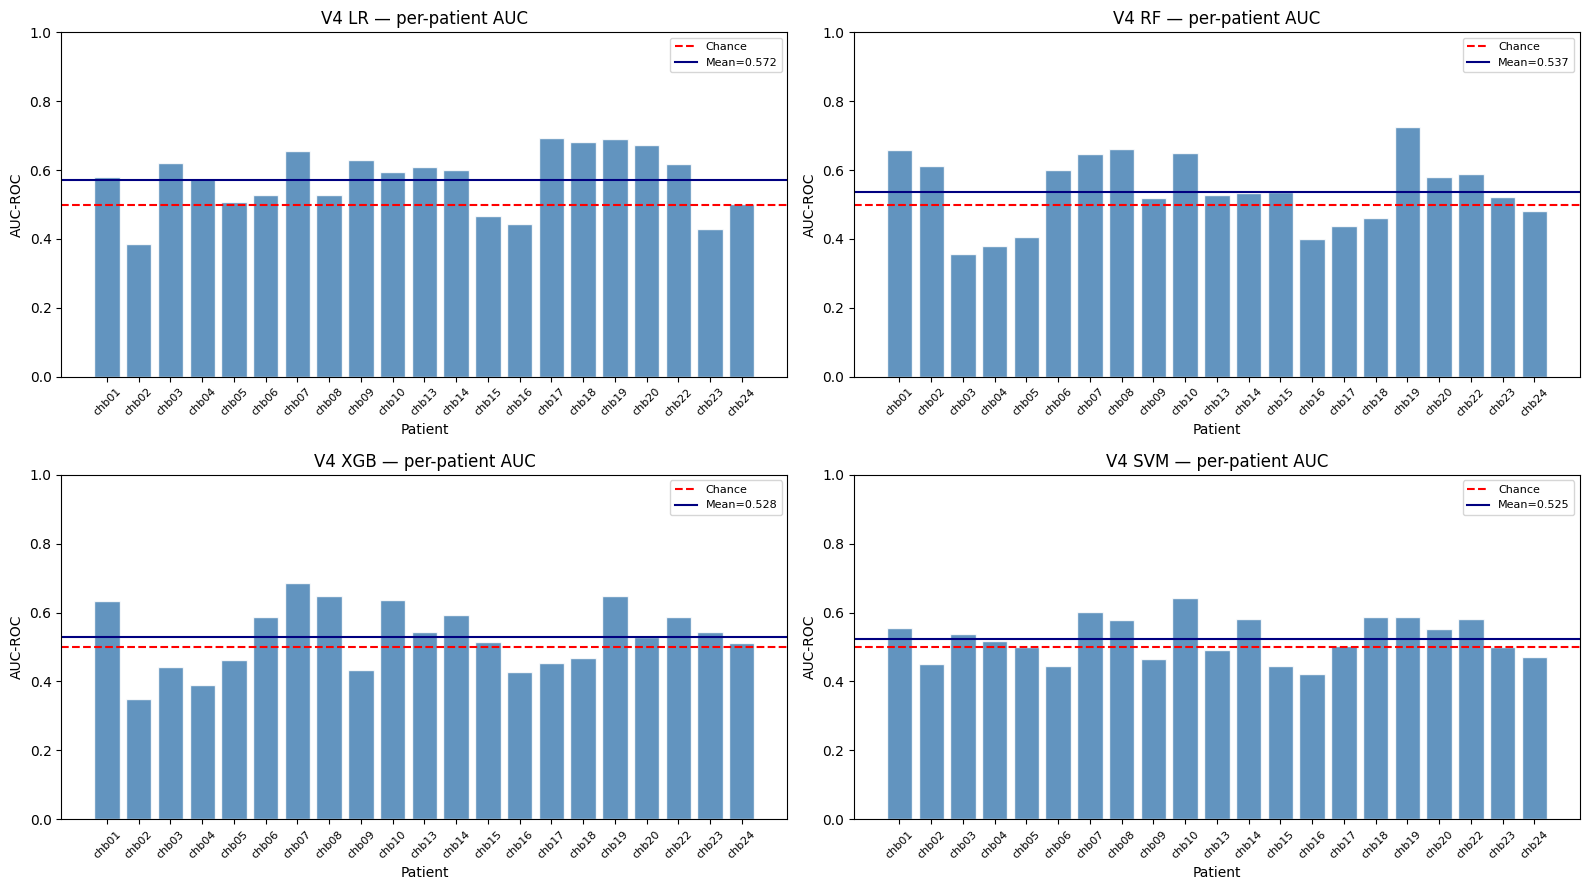

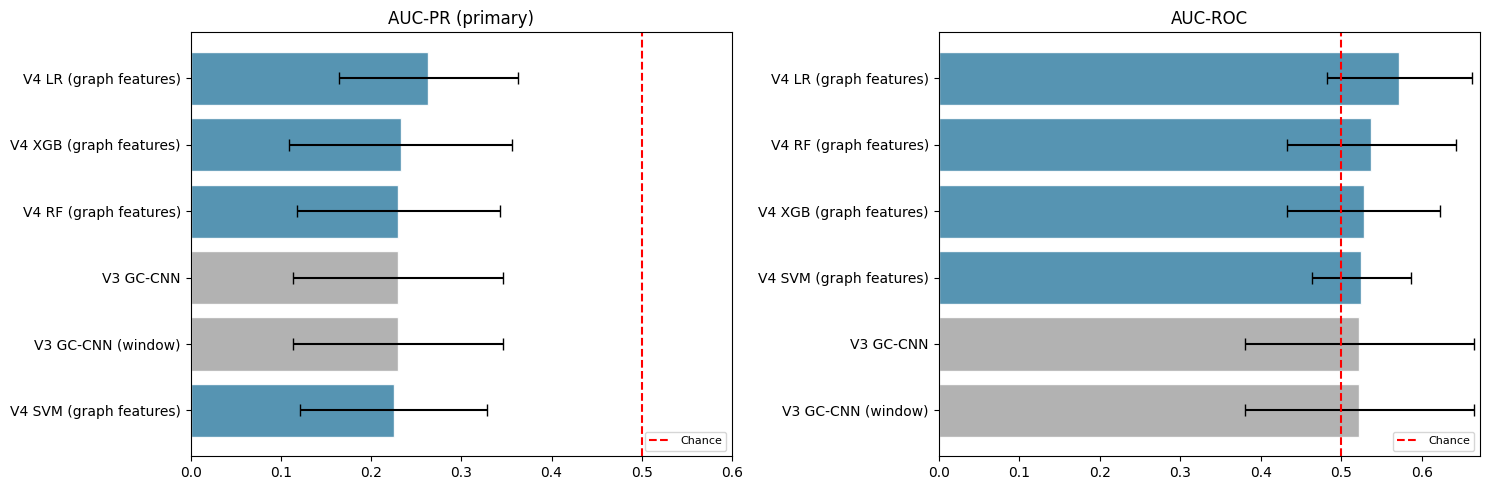

\nSaved: results/v4_per_patient_auc.png
Saved: results/v4_method_comparison.png


In [10]:
# Cell 9 — Plot per-patient AUC for each V4 model + side-by-side comparison

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, (name, df) in zip(axes.ravel(), all_results.items()):
    df_p = df.sort_values('patient')
    ax.bar(df_p['patient'], df_p['auc'], color='steelblue', edgecolor='white', alpha=0.85)
    ax.axhline(0.5, color='red', linestyle='--', label='Chance')
    ax.axhline(df_p['auc'].mean(), color='navy', linestyle='-',
               label=f'Mean={df_p["auc"].mean():.3f}')
    ax.set_title(f'V4 {name} — per-patient AUC')
    ax.set_xlabel('Patient'); ax.set_ylabel('AUC-ROC')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(df_p['patient'], rotation=45, fontsize=8)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v4_per_patient_auc.png'), dpi=130)
plt.show()


# ── Method comparison bar chart (mean ± std) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metrics_to_plot = [('auc_pr_mean', 'auc_pr_std', 'AUC-PR (primary)'),
                   ('auc_mean',    'auc_std',    'AUC-ROC')]
for ax, (m_col, s_col, title) in zip(axes, metrics_to_plot):
    plot_df = comp_df.dropna(subset=[m_col]).sort_values(m_col)
    colors  = ['#48a' if 'V4' in s else '#aaa' for s in plot_df['method']]
    ax.barh(plot_df['method'], plot_df[m_col],
            xerr=plot_df[s_col], color=colors, edgecolor='white', alpha=0.9, capsize=4)
    ax.axvline(0.5, color='red', linestyle='--', label='Chance')
    ax.set_title(title)
    ax.set_xlim(0, max(0.6, plot_df[m_col].max() + 0.1))
    ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v4_method_comparison.png'), dpi=130)
plt.show()

print(f'\\nSaved: results/v4_per_patient_auc.png')
print(f'Saved: results/v4_method_comparison.png')

## 9 · Final summary

What this notebook demonstrates and how it fits the thesis.

In [11]:
# Cell 10 — Final text summary
print('═' * 68)
print('V4 — Patient-invariant ML pipeline')
print('═' * 68)
print(f'\\nPatients          : {len(patient_ids)}')
print(f'Feature dim       : {len(FEATURE_NAMES)}  (vs 324 raw GC cells)')
print(f'LOPO folds        : {len(patient_ids)}')
print(f'\\nPatient-ID probe (lower → more patient-invariant):')
print(f'   Raw GC (324d)      AUC-multi acc = {acc_raw :.3f}  (×{acc_raw /chance:.1f} chance)')
print(f'   Engineered (67d)   AUC-multi acc = {acc_eng :.3f}  (×{acc_eng /chance:.1f} chance)')
print(f'   Asymmetry (153d)   AUC-multi acc = {acc_asym:.3f}  (×{acc_asym/chance:.1f} chance)')
print(f'\\n══ LOPO mean ± std (V4 models) ' + '═'*38)
print(summary_df[['model'] + METRIC_KEYS].to_string(index=False))
print()
print('═' * 68)
print('Interpretation for thesis:')
print('═' * 68)
print('• If V4 best AUC-PR significantly > V3 CNN AUC-PR (Wilcoxon p < 0.05),')
print('  this supports the methodological claim that the failure mode')
print('  documented by Shafiezadeh (2024) is partly mitigable by')
print('  patient-invariant feature engineering + low-capacity ML.')
print('• If V4 still ≈ chance, this is itself a publishable finding:')
print('  directed connectivity on scalp EEG does NOT carry cross-patient')
print('  preictal signal beyond what spectral/correlation features do,')
print('  consistent with the volume-conduction concern raised by')
print('  Nolte et al. (2004) and Schelter et al. (2006).')
print('• Either way, the comparison answers RQ3 directly.')
print('═' * 68)

════════════════════════════════════════════════════════════════════
V4 — Patient-invariant ML pipeline
════════════════════════════════════════════════════════════════════
\nPatients          : 21
Feature dim       : 67  (vs 324 raw GC cells)
LOPO folds        : 21
\nPatient-ID probe (lower → more patient-invariant):
   Raw GC (324d)      AUC-multi acc = 0.993  (×20.8 chance)
   Engineered (67d)   AUC-multi acc = 0.866  (×18.2 chance)
   Asymmetry (153d)   AUC-multi acc = 0.699  (×14.7 chance)
\n══ LOPO mean ± std (V4 models) ══════════════════════════════════════
model    auc  auc_pr  sensitivity  specificity  precision     f1  balanced_accuracy  fpr_per_hour
   LR 0.5721  0.2634       0.6370       0.5241     0.2770 0.3297             0.5805        1.7021
   RF 0.5374  0.2300       0.6895       0.4468     0.2442 0.3217             0.5681        1.7544
  XGB 0.5280  0.2329       0.6933       0.4149     0.2672 0.3131             0.5541        1.7521
  SVM 0.5247  0.2251       0.6773   